In [37]:
import numpy as np
import pandas as pd 

In [ ]:
df = pd.read_csv("survey_results_public.csv")

In [39]:
del df['Respondent']

In [40]:
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Male', 'Female'] else ('other' if pd.notna(x) else x))
df['SexualOrientation'] = df['SexualOrientation'].apply(lambda x: x if x in ['Straight or heterosexual'] else ('other' if pd.notna(x) else x))


In [41]:
top_countries = [
    "United States", "India", "Germany", "United Kingdom", "Canada", "Russian Federation", 
    "France", "Brazil", "Poland", "Australia", "Netherlands", "Spain", "Italy", "Ukraine", 
    "Sweden", "Pakistan", "China", "Switzerland", "Turkey", "Israel"
]

# Process the 'Country' column
df['Country'] = df['Country'].apply(lambda x: x if x in top_countries else (x if pd.isna(x) else "Other"))

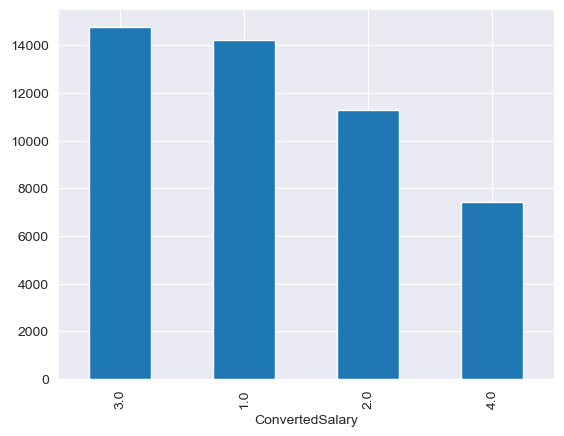

In [42]:
def disc_income_total(value):
            if pd.isna(value):  # Handle NaN values
                return None
            elif value < 30000:
                return 1
            elif value < 60000:
                return 2
            elif value < 120000:
                return 3
            else:
                return 4
df['ConvertedSalary'].apply(disc_income_total).value_counts().plot(kind='bar')
df['ConvertedSalary'] = df['ConvertedSalary'].apply(disc_income_total)

In [43]:

for column in df.columns:
    if df[column].dtype == 'object':  # Categorical columns
        df[column].fillna('N/A', inplace=True)
        df[column] =   df[column].astype(str)
    else:  # Numerical columns
        df[column].fillna(-1, inplace=True)


In [44]:
ordinal_mappings = {
    "Gender": {"N/A": -1, "other": 0, "Female": 1, "Male": 2},
    "SexualOrientation": {"N/A": -1, "other": 0, "Straight or heterosexual": 1},
    "YearsCoding": {
        "N/A": -1, "0-2 years": 0, "3-5 years": 1, "6-8 years": 2, "9-11 years": 3,
        "12-14 years": 4, "15-17 years": 5, "18-20 years": 6, "21-23 years": 7,
        "24-26 years": 8, "27-29 years": 9, "30 or more years": 10
    },
    "YearsCodingProf": {
        "N/A": -1, "0-2 years": 0, "3-5 years": 1, "6-8 years": 2, "9-11 years": 3,
        "12-14 years": 4, "15-17 years": 5, "18-20 years": 6, "21-23 years": 7,
        "24-26 years": 8, "27-29 years": 9, "30 or more years": 10
    },
    "JobSatisfaction": {
        "N/A": -1, "Extremely dissatisfied": 0, "Moderately dissatisfied": 1,
        "Slightly dissatisfied": 2, "Neither satisfied nor dissatisfied": 3,
        "Slightly satisfied": 4, "Moderately satisfied": 5, "Extremely satisfied": 6
    },
    "CareerSatisfaction": {
        "N/A": -1, "Extremely dissatisfied": 0, "Moderately dissatisfied": 1,
        "Slightly dissatisfied": 2, "Neither satisfied nor dissatisfied": 3,
        "Slightly satisfied": 4, "Moderately satisfied": 5, "Extremely satisfied": 6
    },
    "Employment": {
        "N/A": -1, "Not employed, and not looking for work": 0,
        "Not employed, but looking for work": 1, "Retired": 2,
        "Employed part-time": 3, "Independent contractor, freelancer, or self-employed": 4,
        "Employed full-time": 5
    }
}
ordinal_mappings.update({
    "CheckInCode": {
        "N/A": -1, "Never": 0, "Less than once per month": 1, 
        "Weekly or a few times per month": 2, "A few times per week": 3,
        "Once a day": 4, "Multiple times per day": 5
    },
    "StackOverflowParticipate": {
        "N/A": -1, "I have never participated in Q&A on Stack Overflow": 0,
        "Less than once per month or monthly": 1, "A few times per month or weekly": 2,
        "A few times per week": 3, "Daily or almost daily": 4, "Multiple times per day": 5
    },
    "TimeFullyProductive": {
        "N/A": -1, "Less than a month": 0, "One to three months": 1,
        "Three to six months": 2, "Six to nine months": 3,
        "Nine months to a year": 4, "More than a year": 5
    },
    "HoursComputer": {
        "N/A": -1, "Less than 1 hour": 0, "1 - 4 hours": 1, "5 - 8 hours": 2,
        "9 - 12 hours": 3, "Over 12 hours": 4
    },
    "HoursOutside": {
        "N/A": -1, "Less than 30 minutes": 0, "30 - 59 minutes": 1, 
        "1 - 2 hours": 2, "3 - 4 hours": 3, "Over 4 hours": 4
    },
    "HypotheticalTools1": {
        "N/A": -1, "Not at all interested": 0, "A little bit interested": 1, 
        "Somewhat interested": 2, "Very interested": 3, "Extremely interested": 4
    },
    "HypotheticalTools2": {
        "N/A": -1, "Not at all interested": 0, "A little bit interested": 1, 
        "Somewhat interested": 2, "Very interested": 3, "Extremely interested": 4
    },
    "HypotheticalTools3": {
        "N/A": -1, "Not at all interested": 0, "A little bit interested": 1, 
        "Somewhat interested": 2, "Very interested": 3, "Extremely interested": 4
    },
    "HypotheticalTools4": {
        "N/A": -1, "Not at all interested": 0, "A little bit interested": 1, 
        "Somewhat interested": 2, "Very interested": 3, "Extremely interested": 4
    },
    "HypotheticalTools5": {
        "N/A": -1, "Not at all interested": 0, "A little bit interested": 1, 
        "Somewhat interested": 2, "Very interested": 3, "Extremely interested": 4
    },
    "AgreeDisagree1": {
        "N/A": -1, "Strongly disagree": 0, "Disagree": 1, 
        "Neither Agree nor Disagree": 2, "Agree": 3, "Strongly agree": 4
    },
    "AgreeDisagree2": {
        "N/A": -1, "Strongly disagree": 0, "Disagree": 1, 
        "Neither Agree nor Disagree": 2, "Agree": 3, "Strongly agree": 4
    },
    "AgreeDisagree3": {
        "N/A": -1, "Strongly disagree": 0, "Disagree": 1, 
        "Neither Agree nor Disagree": 2, "Agree": 3, "Strongly agree": 4
    },
    "AdsAgreeDisagree1": {
        "N/A": -1, "Strongly disagree": 0, "Somewhat disagree": 1, 
        "Neither agree nor disagree": 2, "Somewhat agree": 3, "Strongly agree": 4
    },
    "AdsAgreeDisagree2": {
        "N/A": -1, "Strongly disagree": 0, "Somewhat disagree": 1, 
        "Neither agree nor disagree": 2, "Somewhat agree": 3, "Strongly agree": 4
    },
    "AdsAgreeDisagree3": {
        "N/A": -1, "Strongly disagree": 0, "Somewhat disagree": 1, 
        "Neither agree nor disagree": 2, "Somewhat agree": 3, "Strongly agree": 4
    },
    "SurveyEasy": {
        "N/A": -1, "Very difficult": 0, "Somewhat difficult": 1, 
        "Neither easy nor difficult": 2, "Somewhat easy": 3, "Very easy": 4
    },
    "SkipMeals": {
        "N/A": -1, "Never": 0, "1 - 2 times per week": 1, 
        "3 - 4 times per week": 2, "Daily or almost every day": 3
    },
    "StackOverflowDevStory": {
        "N/A": -1, "No, and I don't know what that is": 0, 
        "No, I know what it is but I don't have one": 1, 
        "No, I have one but it's out of date": 2, "Yes": 3
    },
    "OperatingSystem": {
        "N/A": -1, "BSD/Unix": 0, "MacOS": 1, "Windows": 2, "Linux-based": 3
    },
    "AIDangerous": {
        "N/A": -1, 'Evolving definitions of "fairness" in algorithmic versus human decisions': 0,
        "Algorithms making important decisions": 1, "Increasing automation of jobs": 2,
        'Artificial intelligence surpassing human intelligence ("the singularity")': 3
    },
    "AIInteresting": {
        "N/A": -1, 'Evolving definitions of "fairness" in algorithmic versus human decisions': 0,
        "Algorithms making important decisions": 1, "Increasing automation of jobs": 2,
        'Artificial intelligence surpassing human intelligence ("the singularity")': 3
    }
})
ordinal_mappings.update({
    "Exercise": {
        "N/A": -1, "I don't typically exercise": 0, "1 - 2 times per week": 1, 
        "3 - 4 times per week": 2, "Daily or almost every day": 3
    },
    "EthicsReport": {
        "N/A": -1, "No": 0, "Depends on what it is": 1, 
        "Yes, but only within the company": 2, "Yes, and publicly": 3
    },
    "AIResponsible": {
        "N/A": -1, "Nobody": 0, "Prominent industry leaders": 1, 
        "A governmental or other regulatory body": 2, "The developers or the people creating the AI": 3
    },
    "SurveyTooLong": {
        "N/A": -1, "The survey was too short": 0, 
        "The survey was an appropriate length": 1, "The survey was too long": 2
    },
    "Student": {
        "N/A": -1, "No": 0, "Yes, part-time": 1, "Yes, full-time": 2
    },
    "JobSearchStatus": {
        "N/A": -1, "I am not interested in new job opportunities": 0,
        "I’m not actively looking, but I am open to new opportunities": 1,
        "I am actively looking for a job": 2
    },
    "AIFuture": {
        "N/A": -1, "I don't care about it, or I haven't thought about it.": 0,
        "I'm worried about the dangers more than I'm excited about the possibilities.": 1,
        "I'm excited about the possibilities more than worried about the dangers.": 2
    },
    "AdBlocker": {
        "N/A": -1, "No": 0, "I'm not sure/I don't know": 1, "Yes": 2
    },
    "EthicsChoice": {
        "N/A": -1, "No": 0, "Depends on what it is": 1, "Yes": 2
    },
    "SalaryType": {
        "N/A": -1, "Weekly": 0, "Monthly": 1, "Yearly": 2
    },
    "EthicalImplications": {
        "N/A": -1, "No": 0, "Unsure / I don't know": 1, "Yes": 2
    },
    "StackOverflowConsiderMember": {
        "N/A": -1, "No": 0, "I'm not sure": 1, "Yes": 2
    },
    "AdBlockerDisable": {
        "N/A": -1, "No": 0, "I'm not sure/I can't remember": 1, "Yes": 2
    },
    "StackOverflowJobs": {
        "N/A": -1, "No, I didn't know that Stack Overflow had a jobs board": 0,
        "No, I knew that Stack Overflow had a jobs board but have never used or visited it": 1,
        "Yes": 2
    },
    "OpenSource": {
        "No": 0, "Yes": 1
    },
    "Dependents": {
        "N/A": -1, "No": 0, "Yes": 1
    },
    "Hobby": {
        "No": 0, "Yes": 1
    },
    "Country": {
        "N/A": -1, "Other": 0, "India": 1, "Pakistan": 2, "China": 3, "Brazil": 4,
        "Russian Federation": 5, "Ukraine": 6, "Turkey": 7, "Israel": 8, "Poland": 9,
        "Spain": 10, "Netherlands": 11, "Sweden": 12, "Switzerland": 13, "Australia": 14,
        "Italy": 15, "France": 16, "Germany": 17, "Canada": 18, "United Kingdom": 19,
        "United States": 20
    }
})
ordinal_mappings.update({
    "UndergradMajor": {
        "N/A": -1, "I never declared a major": 0, "Web development or web design": 1, 
        "A health science (ex. nursing, pharmacy, radiology)": 2, "A business discipline (ex. accounting, finance, marketing)": 3, 
        "Fine arts or performing arts (ex. graphic design, music, studio art)": 4, 
        "A social science (ex. anthropology, psychology, political science)": 5, 
        "A humanities discipline (ex. literature, history, philosophy)": 6, 
        "Information systems, information technology, or system administration": 7, 
        "A natural science (ex. biology, chemistry, physics)": 8, 
        "Another engineering discipline (ex. civil, electrical, mechanical)": 9, 
        "Mathematics or statistics": 10, 
        "Computer science, computer engineering, or software engineering": 11
    },
    "StackOverflowRecommend": {
        "N/A": -1, "0 (Not Likely)": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5, "6": 6, 
        "7": 7, "8": 8, "9": 9, "10 (Very Likely)": 10
    },
    "WakeTime": {
     'N/A': -1,
    'Before 5:00 AM': 0,
    'Between 5:00 - 6:00 AM': 1,
    'Between 6:01 - 7:00 AM': 2,
    'Between 7:01 - 8:00 AM': 3,
    'Between 8:01 - 9:00 AM': 4,
    'Between 9:01 - 10:00 AM': 5,
    'Between 10:01 - 11:00 AM': 6,
    'Between 11:01 AM - 12:00 PM': 7,
    'After 12:01 PM': 8,
    'I work night shifts': 9,
    'I do not have a set schedule': 10
    },
    "FormalEducation": {
        "N/A": -1, "I never completed any formal education": 0, "Primary/elementary school": 1, 
        "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2, 
        "Some college/university study without earning a degree": 3, "Associate degree": 4, 
        "Bachelor’s degree (BA, BS, B.Eng., etc.)": 5, "Master’s degree (MA, MS, M.Eng., MBA, etc.)": 6, 
        "Professional degree (JD, MD, etc.)": 7, "Other doctoral degree (Ph.D, Ed.D., etc.)": 8
    },
    "EducationParents": {
        "N/A": -1, "They never completed any formal education": 0, "Primary/elementary school": 1, 
        "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2, 
        "Some college/university study without earning a degree": 3, "Associate degree": 4, 
        "Bachelor’s degree (BA, BS, B.Eng., etc.)": 5, "Master’s degree (MA, MS, M.Eng., MBA, etc.)": 6, 
        "Professional degree (JD, MD, etc.)": 7, "Other doctoral degree (Ph.D, Ed.D., etc.)": 8
    },
    "CompanySize": {
        "N/A": -1, "Fewer than 10 employees": 0, "10 to 19 employees": 1, "20 to 99 employees": 2,
        "100 to 499 employees": 3, "500 to 999 employees": 4, "1,000 to 4,999 employees": 5,
        "5,000 to 9,999 employees": 6, "10,000 or more employees": 7
    },
    "UpdateCV": {
        "N/A": -1, "A recruiter contacted me": 0, "I did not receive an expected change in compensation": 1, 
        "A friend told me about a job opportunity": 2, "I received bad news about the future of my company or department": 3, 
        "I had a negative experience or interaction at work": 4, "I received negative feedback on my job performance": 5, 
        "My job status or other personal status changed": 6, "I saw an employer’s advertisement": 7
    },
    "Age": {
        "N/A": -1, "Under 18 years old": 0, "18 - 24 years old": 1, "25 - 34 years old": 2, 
        "35 - 44 years old": 3, "45 - 54 years old": 4, "55 - 64 years old": 5, "65 years or older": 6
    },
    "HopeFiveYears": {
        "N/A": -1, "Working in a career completely unrelated to software development": 0, 
        "Working as a product manager or project manager": 1, "Retirement": 2, 
        "Working as an engineering manager or other functional manager": 3, 
        "Working as a founder or co-founder of my own company": 4, 
        "Doing the same work": 5, "Working in a different or more specialized technical role than the one I'm in now": 6
    },
    "StackOverflowVisit": {
        "N/A": -1, "I have never visited Stack Overflow (before today)": 0, 
        "Less than once per month or monthly": 1, "A few times per week": 2, 
        "A few times per month or weekly": 3, "Daily or almost daily": 4, 
        "Multiple times per day": 5
    },
    "NumberMonitors": {
        "N/A": -1, "1": 0, "2": 1, "3": 2, "4": 3, "More than 4": 4
    },
    "LastNewJob": {
        "N/A": -1, "I've never had a job": 0, "Less than a year ago": 1, "Between 1 and 2 years ago": 2, 
        "Between 2 and 4 years ago": 3, "More than 4 years ago": 4
    }
})

In [45]:
for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping) 

In [46]:
columns = ['Gender', 'SexualOrientation', 'UndergradMajor',
       'StackOverflowRecommend', 'WakeTime', 'YearsCoding', 'YearsCodingProf',
       'FormalEducation', 'EducationParents', 'CompanySize', 'UpdateCV', 'Age',
       'JobSatisfaction', 'CareerSatisfaction', 'HopeFiveYears',
       'StackOverflowVisit', 'Employment', 'CheckInCode',
       'StackOverflowParticipate', 'TimeFullyProductive', 'HoursComputer',
       'HoursOutside', 'HypotheticalTools3', 'HypotheticalTools1',
       'HypotheticalTools5', 'HypotheticalTools4', 'HypotheticalTools2',
       'AgreeDisagree3', 'AdsAgreeDisagree3', 'NumberMonitors', 'LastNewJob',
       'AgreeDisagree1', 'AgreeDisagree2', 'AdsAgreeDisagree2', 'SurveyEasy',
       'AdsAgreeDisagree1', 'SkipMeals', 'StackOverflowDevStory',
       'OperatingSystem', 'AIDangerous', 'AIInteresting', 'Exercise',
       'EthicsReport', 'AIResponsible', 'SurveyTooLong', 'Student',
       'JobSearchStatus', 'AIFuture', 'AdBlocker', 'EthicsChoice',
       'SalaryType', 'EthicalImplications', 'StackOverflowConsiderMember',
       'AdBlockerDisable', 'StackOverflowJobs', 'OpenSource', 'Dependents',
       'Hobby', 'ConvertedSalary', 'Country']
df = df[columns]

In [47]:
df.nunique()

Gender                          4
SexualOrientation               3
UndergradMajor                 13
StackOverflowRecommend         12
WakeTime                       12
YearsCoding                    12
YearsCodingProf                12
FormalEducation                10
EducationParents               10
CompanySize                     9
UpdateCV                        9
Age                             8
JobSatisfaction                 8
CareerSatisfaction              8
HopeFiveYears                   8
StackOverflowVisit              7
Employment                      7
CheckInCode                     7
StackOverflowParticipate        7
TimeFullyProductive             7
HoursComputer                   6
HoursOutside                    6
HypotheticalTools3              6
HypotheticalTools1              6
HypotheticalTools5              6
HypotheticalTools4              6
HypotheticalTools2              6
AgreeDisagree3                  6
AdsAgreeDisagree3               6
NumberMonitors